In [ ]:
! pip install catboost


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
!pip install xgboost


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# modelling
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('data/StudentsPerformance.csv')

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# preparing for x and y

In [ ]:
X = df.drop(columns = ['math score'],axis=1)

In [ ]:
X

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [ ]:
y = df['math score']

In [ ]:
# create columns transformations

num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('StandardScaler', numeric_transformer, num_features),
        ('OneHotEncoder', oh_transformer, cat_features)
    ]
)

In [ ]:
X = preprocessor.fit_transform(X)

In [ ]:
X.shape

(1000, 19)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((800, 19), (200, 19), (800,), (200,))

# create evaluate model

In [ ]:
def evaluate_model(true,predictes):
    mae = mean_absolute_error(true,predictes)
    mse = mean_squared_error(true,predictes)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true,predictes)
    return mae,mse,rmse,r2_square

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'KNN Regressor': KNeighborsRegressor(),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'AdaBoost Regressor': AdaBoostRegressor(),
    'Gradient Boosting Regressor': GradientBoostingRegressor(),
    'XGBoost Regressor': XGBRegressor(),
    'CatBoost Regressor': CatBoostRegressor(verbose=0)
}

model_list = []

r2_list = []

for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    # make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate train and test dataset

    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(f'{list(models.keys())[i]}: ')
    model_list.append(list(models.keys())[i])

    print('Model performance for training dataset:')

    print(f'MAE: {model_train_mae}')
    print(f'RMSE: {model_train_rmse}')
    print(f'R2 Square: {model_test_r2}')

    print('-----------------------------')

    print('Model performance for testing dataset:')
    print(f'MAE: {model_test_mae}')
    print(f'RMSE: {model_test_rmse}')
    print(f'R2 Square: {model_test_r2}')
    print('=============================')
    
    r2_list.append(model_test_r2)

    print('=' *35)
    print('\n\n')


Linear Regression: 
Model performance for training dataset:
MAE: 4.266711846071956
RMSE: 5.323050852720514
R2 Square: 0.8804332983749565
-----------------------------
Model performance for testing dataset:
MAE: 4.214763142474851
RMSE: 5.393993869732843
R2 Square: 0.8804332983749565



Ridge Regression: 
Model performance for training dataset:
MAE: 4.26498782372598
RMSE: 5.323324922741654
R2 Square: 0.880593148502874
-----------------------------
Model performance for testing dataset:
MAE: 4.211100688014258
RMSE: 5.390387016935634
R2 Square: 0.880593148502874



Lasso Regression: 
Model performance for training dataset:
MAE: 5.206296077972952
RMSE: 6.593807540619167
R2 Square: 0.825320079562973
-----------------------------
Model performance for testing dataset:
MAE: 5.157879138921817
RMSE: 6.519688056285626
R2 Square: 0.825320079562973



KNN Regressor: 
Model performance for training dataset:
MAE: 4.51675
RMSE: 5.712753276660913
R2 Square: 0.7837702557426202
--------------------------

# result

In [ ]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name','R2 Score']).sort_values(by='R2 Score',ascending=False)

,Model Name,R2 Score
1,Ridge Regression,0.880593
0,Linear Regression,0.880433
7,Gradient Boosting Regressor,0.872114
9,CatBoost Regressor,0.851632
6,AdaBoost Regressor,0.849127
5,Random Forest Regressor,0.849060
2,Lasso Regression,0.825320
8,XGBoost Regressor,0.821221
3,KNN Regressor,0.783770
4,Decision Tree Regressor,0.742026


# Linear Regression

In [ ]:
lin_model = LinearRegression()
lin_model = lin_model.fit(X_train,y_train) 
y_pred = lin_model.predict(X_test)

score = r2_score(y_test,y_pred)*100
print(f'R2 Score for Linear Regression: {score:.2f}%')

R2 Score for Linear Regression: 88.04%


# plot Y_pred and y_test

Text(0.5, 1.0, 'Actual vs Predicted')

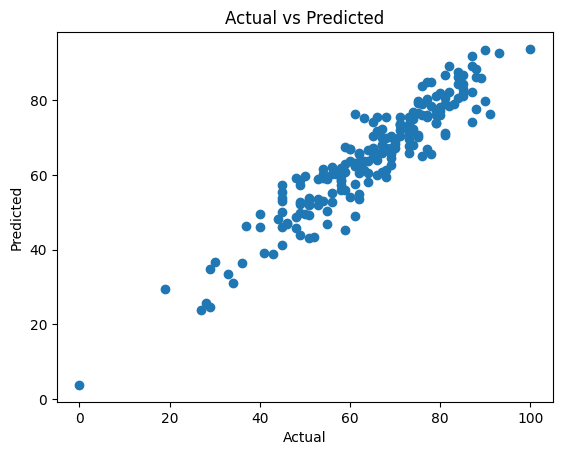

In [ ]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')

<Axes: xlabel='math score'>

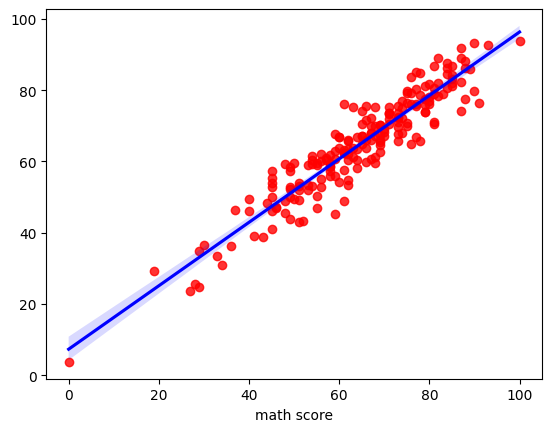

In [ ]:
sns.regplot(x=y_test, y=y_pred, scatter_kws={'color':'red'}, line_kws={'color':'blue'})

# diff between actual and predicted values

In [ ]:
pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'difference': y_test - y_pred})
pred_df.head()

,Actual,Predicted,difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
